## Kliuev Dmitrii second dz

## Problem 1

Let $f(x) = 2\sin x - \cos{2x}$. Write a function `beauty_derivative_plot` that takes a point $x$ and plots the function $f(x)$ and its derivative $f'(x)$ in the range $x \in [-2\pi, 2\pi]$. The function should also plot the tangent line to the function at the point $x$. 

### My solution:

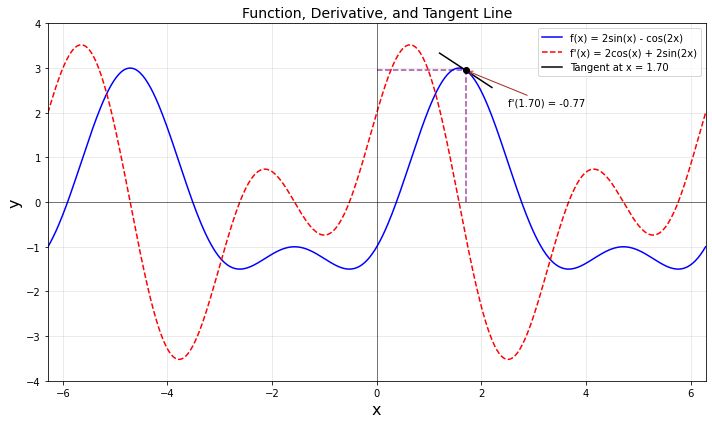

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def beauty_derivative_plot(x0):    
    f = lambda x: 2 * np.sin(x) - np.cos(2*x)
    df = lambda x: 2 * np.cos(x) + 2 * np.sin(2*x)
    
    
    x_vals = np.linspace(-2*np.pi, 2*np.pi, 500)
    y_vals = f(x_vals)
    dy_vals = df(x_vals)
    
    y0 = f(x0)
    dy0 = df(x0)
    

    y_tangent = y0 + dy0 * (x_vals - x0)
    

    dlina = 0.5
    x_short = np.linspace(max(x0 - dlina, x_vals[0]), min(x0 + dlina, x_vals[-1]), 100)
    y_short = y0 + dy0 * (x_short - x0)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, y_vals, label='f(x) = 2sin(x) - cos(2x)', color='blue')
    plt.plot(x_vals, dy_vals, '--', label="f'(x) = 2cos(x) + 2sin(2x)", color='red')
    plt.plot(x_short, y_short, label=f'Tangent at x = {x0:.2f}', color='black')
    plt.scatter([x0], [y0], color='black', zorder=5)
    

    plt.vlines(x0, 0, y0, colors='purple', linestyles='--', alpha=0.7)  
    plt.hlines(y0, 0, x0, colors='purple', linestyles='--', alpha=0.7)  
    

    plt.annotate(f"f'({x0:.2f}) = {dy0:.2f}", 
                xy=(x0, y0), 
                xytext=(x0+0.8, y0-0.8),
                arrowprops=dict(arrowstyle='->', color='brown'))
    
    
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.grid(True, alpha=0.3)
    plt.title('Function, Derivative, and Tangent Line', fontsize=14)
    plt.xlabel('x', fontsize=16)
    plt.ylabel('y', fontsize=16)
    plt.xlim(-2*np.pi, 2*np.pi)
    plt.ylim(-4, 4)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

beauty_derivative_plot(1.7)

## Problem 2

The data in [populations.txt](http://www.scipy-lectures.org/_downloads/populations.txt) describes the populations of hares, lynxes and carrots in northern Canada during 20 years. Get the data with 
```python
np.loadtxt('http://www.scipy-lectures.org/_downloads/populations.txt')
```
and do the following exercises **without for-loops (!!!)**.

### My solution:

- Plot the population size of each species for each year on a single graph. Add legend and axis labels to the plot.

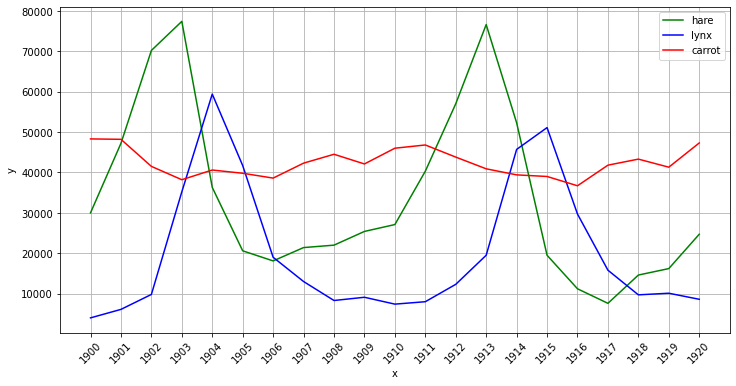

In [2]:
data = np.loadtxt('populations.txt')
col1 = data[:, 0]
col2 = data[:, 1]
col3 = data[:, 2]
col4 = data[:, 3]

plt.figure(figsize=(12, 6))

plt.plot(col1, col2, "g-", label="hare")
plt.plot(col1, col3, "b-", label="lynx")
plt.plot(col1, col4, "r-", label="carrot")
plt.legend(loc="best")
plt.xlabel('x')
plt.ylabel('y')
plt.xticks(col1, rotation=45)
plt.grid(True)
plt.show()

- Find which year each species had the largest population. Mark these years in the plot of populations.

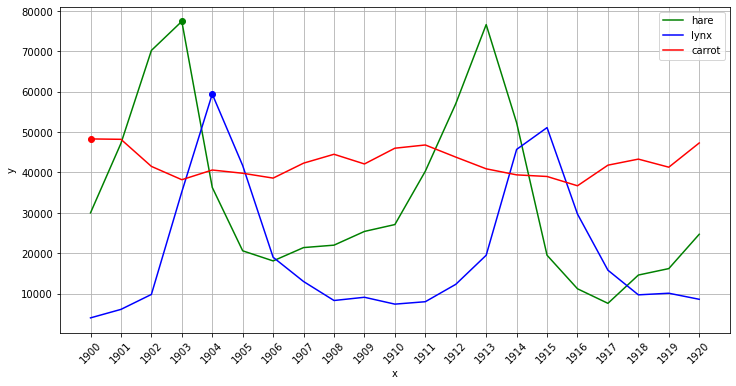

In [3]:
plt.figure(figsize=(12, 6))

plt.plot(col1, col2, "g-", label = "hare")
plt.plot(col1, col3, "b-", label = "lynx")
plt.plot(col1, col4, "r-", label = "carrot")
plt.legend(loc="best")
plt.xlabel('x')
plt.ylabel('y')
plt.xticks(col1, rotation=45)
plt.grid(True)


col2.max()
idx2 = col2.argmax()
plt.plot(col1[idx2], col2[idx2], "go")
col3.max()
idx3 = col3.argmax()
plt.plot(col1[idx3], col3[idx3], "bo")
col4.max()
idx4 = col4.argmax()
plt.plot(col1[idx4], col4[idx4], "ro")

plt.show()

- Assuming total population of hares and lynxes is 100%, plot stacked bar graph showing ratio of each specis for each year in the period.

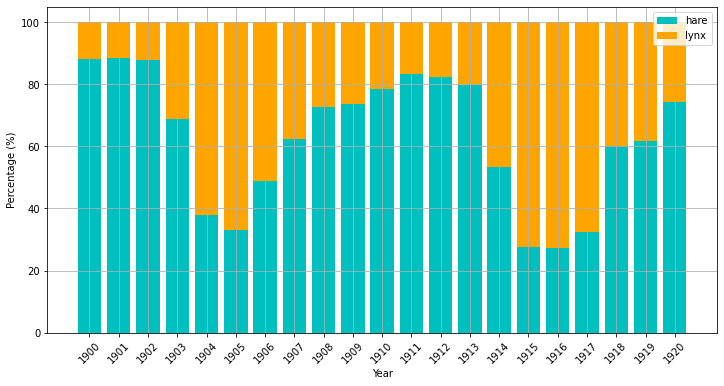

In [4]:
plt.figure(figsize=(12, 6))
total = col2 + col3
hare_ratio = col2 / total * 100
lynx_ratio = col3 / total * 100
plt.bar(col1, hare_ratio, label="hare", color='c')
plt.bar(col1, lynx_ratio, bottom=hare_ratio, label="lynx", color='orange')
plt.grid(True)
plt.legend()
plt.xlabel("Year")
plt.ylabel("Percentage (%)")
plt.xticks(col1, rotation=45)
plt.show()

- Find the mean and std of the populations of each species. Plot the historgam of population for each species and show mean values with vertical line. Show each histogram in a separate plot. Arrange 3 plots in a row.

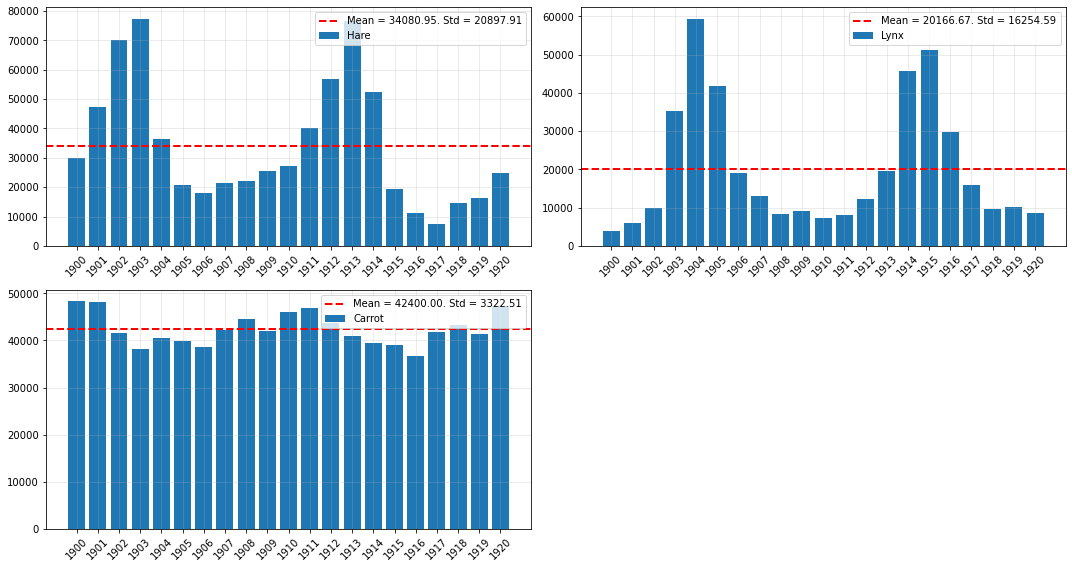

In [5]:
mean_hare = col2.mean()
mean_lynx = col3.mean()
mean_carrot = col4.mean()

std_hare = col2.std()
std_lynx = col3.std()
std_carrot = col4.std()

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.bar(col1, col2, label="Hare")
plt.grid(True, alpha=0.3)
plt.xticks(col1, rotation=45)
plt.axhline(mean_hare, linestyle='--', color='red', linewidth=2,
            label=f'Mean = {mean_hare:.2f}. Std = {std_hare:.2f}')
plt.legend()


plt.subplot(2, 2, 2)
plt.bar(col1, col3, label="Lynx")
plt.grid(True, alpha=0.3)
plt.xticks(col1, rotation=45)
plt.axhline(mean_lynx, linestyle='--', color='red', linewidth=2,
            label=f'Mean = {mean_lynx:.2f}. Std = {std_lynx:.2f}')
plt.legend()


plt.subplot(2, 2, 3)
plt.bar(col1, col4, label="Carrot")
plt.grid(True, alpha=0.3)
plt.xticks(col1, rotation=45)
plt.axhline(mean_carrot, linestyle='--', color='red', linewidth=2,
            label=f'Mean = {mean_carrot:.2f}. Std = {std_carrot:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

- Find which species (hares or lynxes) has the largest population for each year. Print the result as [H, H, L, H, ...]. Plot a pie chart showing the ratio of "H" and "L" values.

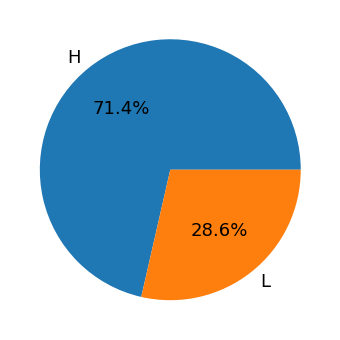

In [6]:
mask = col2 > col3
labels = np.where(mask, "H", "L")
H_count = np.sum(labels == "H")
L_count = np.sum(labels == "L")

plt.figure(figsize=(12, 6))
plt.pie([H_count, L_count], 
        labels=["H", "L"], 
        autopct="%1.1f%%",
        textprops={'fontsize': 18})
plt.show()

- Plot the change in the hare population and in the lynx population for each year. Find the correlation coefficient between the both time series.

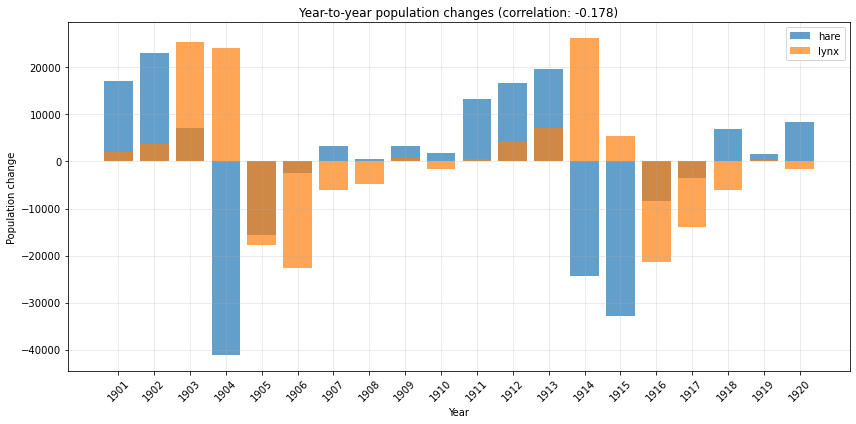

In [7]:
COL2 = col2[1:] - col2[:-1]  
COL3 = col3[1:] - col3[:-1]  

correlation = np.corrcoef(COL2, COL3)[0, 1]

plt.figure(figsize=(12, 6))
plt.bar(col1[1:], COL2, alpha=0.7, label="hare")
plt.bar(col1[1:], COL3, alpha=0.7, label="lynx")
plt.grid(True, alpha=0.3)
plt.xticks(col1[1:], rotation=45)
plt.xlabel("Year")
plt.ylabel("Population change")
plt.legend()
plt.title(f"Year-to-year population changes (correlation: {correlation:.3f})")
plt.tight_layout()
plt.show()

- Using a scatter plot, show the population of hares vs lynxes by year (each point corresponds to a particular year, and the point coordinates correspond to the population of the two species in that year).

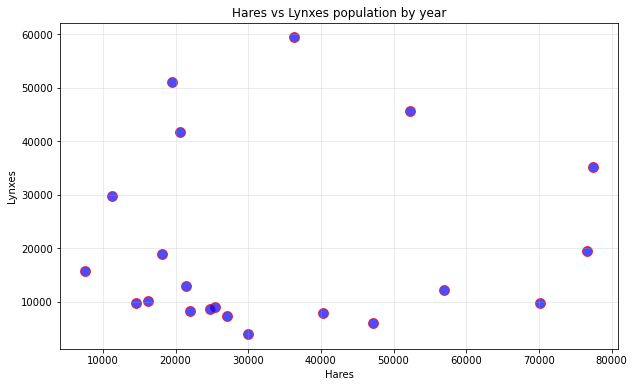

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(col2, col3, alpha=0.7, color='blue', edgecolors='red', s=100)
plt.xlabel("Hares")
plt.ylabel("Lynxes")
plt.grid(True, alpha=0.3)
plt.title("Hares vs Lynxes population by year")
plt.show()

- Assume the population of hares in 1920 is unknown. Suggest a way to estimate this value. Compare an estimated value
with the true value and print a ratio of the error to the true value.

In [9]:
print("Оценка численности зайцев в 1920 году")

# Способ 1: среднее за последние 2 года (1918-1919)
estimate1 = np.mean(col2[-3:-1])
print(f"Оценка через среднее за 1918-1919: {estimate1:.0f}")

# Способ 2: взвешенное среднее (больший вес для более поздних лет)
weights = [0.1, 0.2, 0.3, 0.4]  # веса для 1916, 1917, 1918, 1919
estimate2 = np.average(col2[-5:-1], weights=weights)
print(f"Оценка через взвешенное среднее: {estimate2:.0f}")

# Истинное значение
true_value = col2[-1]
print(f"\nРеальное значение в 1920 году: {true_value:.0f}")

# Вычисляем ошибки
error1 = np.abs(estimate1 - true_value)
error2 = np.abs(estimate2 - true_value)

print(f"Метод 1: ошибка = {error1:.0f} ({error1/true_value*100:.1f}%)")
print(f"Метод 2: ошибка = {error2:.0f} ({error2/true_value*100:.1f}%)")

Оценка численности зайцев в 1920 году
Оценка через среднее за 1918-1919: 15400
Оценка через взвешенное среднее: 13500

Реальное значение в 1920 году: 24700
Метод 1: ошибка = 9300 (37.7%)
Метод 2: ошибка = 11200 (45.3%)
